In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
import os
from pathlib import Path



In [2]:
project_dir = str(Path("/Users/ramzyalmulla/research/smearlab/keypoint_moseq_JoMouse_s5/"))
config = lambda: kpms.load_config(project_dir)

In [4]:
sleap_file = str(Path("/Users/ramzyalmulla/research/smearlab/data/clickbait-motivate/bonsai/JoMouse/0001/s5/04062026_0001_s5.avi.slp"))  # any .slp or .h5 file with predictions for a single video
sleap_dir = str(Path("/Users/ramzyalmulla/research/smearlab/data/clickbait-motivate/bonsai/JoMouse/0001/"))
video_dir = str(Path("/Users/ramzyalmulla/research/smearlab/data/clickbait-motivate/bonsai/JoMouse/0001/"))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
if not os.path.exists(project_dir):
    kpms.setup_project(project_dir, sleap_file=sleap_file,video_dir=video_dir) 


In [95]:
# load data 
keypoint_data_path = sleap_file  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

Loading keypoints: 100%|██████████████████| 1/1 [00:01<00:00,  1.55s/it]


In [92]:
coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


In [97]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [98]:
%matplotlib ipympl
kpms.noise_calibration(project_dir, coordinates, confidences, **config())


error_annotations.csv already exists. Continuing will overwrite the existing file (start noise calibration from scratch). Do you want to continue? (y/n) n


>=90.0% of variance exlained by 3 components.


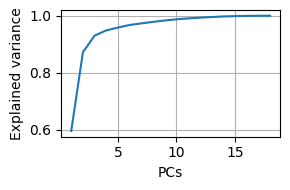

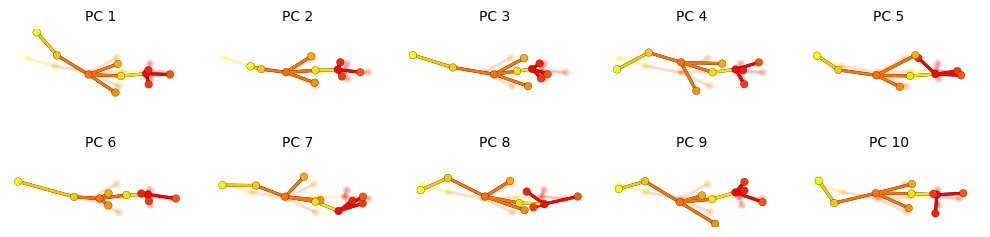

In [99]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [100]:
kpms.update_config(project_dir, latent_dim=3)

In [101]:
kpms.update_config(
    project_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

In [103]:
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


In [107]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# # optionally modify kappa
# model = kpms.update_hypparams(model, kappa=500)

In [108]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, jitter=1e-1,ar_only=True, num_iters=num_ar_iters
)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_JoMouse_s5/2026_04_09-14_49_26


  0%|                                            | 0/51 [00:00<?, ?it/s]

Early termination of fitting: NaNs encountered
  - 702100 NaNs found in noise_prior
  - 702100 NaNs found in states/s

For additional information, see https://keypoint-moseq.readthedocs.io/en/latest/troubleshooting.html#nans-during-fitting

In [49]:

# load model checkpoint
# model, data, metadata, current_iter = kpms.load_checkpoint(
#     project_dir, model_name, iteration=num_ar_iters
# )

# modify kappa to maintain the desired syllable time-scale
model = kpms.update_hypparams(model, kappa=1e4)

# run fitting for an additional 500 iters
model = kpms.fit_model(
    model,
    data,
    metadata,
    project_dir,
    model_name,
    jitter=1e-2,
    ar_only=True,
    num_iters=50
)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_JoMouse_s5/2026_04_09-14_03_16


  0%|                                            | 0/51 [00:00<?, ?it/s]
